# Product Analytics Project

This project simulates product usage data for a healthcare SaaS platform. The goal is to demonstrate common product analytics techniques using Python and pandas, including cohort retention analysis, conversion funnel analysis, engagement KPI design, and user drop-off detection.

The synthetic dataset contains user sign-up information and application events such as logins, opening patient charts, accepting AI insights, dismissing insights, and documenting visits. Although the data are simulated, the analyses mirror those commonly performed by product analysts to evaluate user engagement and product adoption.

1. Generate synthetic event dataset
2. Explore the data
3. Weekly retention cohort analysis
4. Conversion funnel
5. Engagement KPI
6. Drop-off detection
7. Business recommendations

## Generate a Synthetic Event Dataset

Since real product data are not publicly available, this notebook begins by generating a synthetic dataset.

The dataset includes 120 clinicians (users) who sign up over a five-week period. Each clinician generates a random number of product events over the following ten weeks. Every event contains:

- **user_id** – unique clinician identifier
- **signup_date** – when the clinician joined the platform
- **event_date** – when an action occurred
- **event_type** – one of five common product interactions:
  - login
  - opened_chart
  - accepted_insight
  - dismissed_insight
  - documented


In [49]:
import numpy as np
import pandas as pd

np.random.seed(42)

n_users = 120
n_events = 1000

users = pd.DataFrame({
    "user_id": range(1, n_users + 1),
    "signup_date": pd.to_datetime("2025-01-01") +
                   pd.to_timedelta(
                       np.random.randint(0, 35, n_users),
                       unit="D"
                   )
})

event_types = [
    "login",
    "opened_chart",
    "accepted_insight",
    "dismissed_insight",
    "documented"
]

# iterrows() is appropriate for this small synthetic dataset (~120 users).
# In production, where millions of events may be generated or processed,
# a vectorized NumPy approach would be more efficient.

rows = []

for _, user in users.iterrows():

    num_events = np.random.poisson(8) + 2

    for _ in range(num_events):

        days_after_signup = np.random.randint(0, 70)

        event_date = (
            user.signup_date +
            pd.Timedelta(days=days_after_signup)
        )

        event = np.random.choice(
            event_types,
            p=[0.35, 0.25, 0.15, 0.10, 0.15]
        )

        rows.append([
            user.user_id,
            user.signup_date,
            event_date,
            event
        ])

events = pd.DataFrame(
    rows,
    columns=[
        "user_id",
        "signup_date",
        "event_date",
        "event_type"
    ]
)

events = events.sort_values("event_date").reset_index(drop=True)

events.head()

,user_id,signup_date,event_date,event_type
0,16,2025-01-02,2025-01-02,documented
1,16,2025-01-02,2025-01-02,login
2,45,2025-01-02,2025-01-03,login
3,99,2025-01-01,2025-01-03,login
4,36,2025-01-02,2025-01-03,dismissed_insight


## Prepare Data for Cohort Analysis

Retention analysis groups users into cohorts based on when they first signed up. Users are then tracked over subsequent weeks to determine whether they continue using the product.

This section creates:

- the signup week for each user
- the week during which each event occurred
- the number of weeks since signup (cohort length)

These variables form the foundation for calculating weekly retention rates.

In [50]:
events["signup_week"] = (
    events["signup_date"]
    .dt.to_period("W")
    .apply(lambda r: r.start_time)
)

events["event_week"] = (
    events["event_date"]
    .dt.to_period("W")
    .apply(lambda r: r.start_time)
)

events["cohort_length"] = (
    (
        events["event_week"] -
        events["signup_week"]
    ).dt.days // 7
)

## Calculate Weekly Retention

The retention table measures the percentage of users from each signup cohort who remain active over time.

The process consists of three steps:

1. Count the number of unique active users in each cohort-week.
2. Determine the original size of each signup cohort.
3. Divide active users by cohort size to calculate the retention percentage.

A weekly retention cohort table (% of each signup cohort still active in weeks 1–8)

Keep only weeks 0–8.

In [51]:
retention = (
    events[
        (events["cohort_length"] >= 0) &
        (events["cohort_length"] <= 8)
    ]
    .groupby(["signup_week", "cohort_length"])["user_id"]
    .nunique()
    .reset_index()
)

Compute cohort sizes

In [52]:
cohort_sizes = (
    users.assign(
        signup_week=users["signup_date"]
        .dt.to_period("W")
        .apply(lambda r: r.start_time)
    )
    .groupby("signup_week")["user_id"]
    .nunique()
)

retention["cohort_size"] = retention["signup_week"].map(cohort_sizes)

retention["retention_rate"] = (
    retention["user_id"] /
    retention["cohort_size"]
)

cohort_table = retention.pivot(
    index="signup_week",
    columns="cohort_length",
    values="retention_rate"
).round(2)

# By convention, every user belongs to their signup cohort in week 0,
# so week-0 retention is defined as 100%.

cohort_table[0] = 1.0

cohort_table = cohort_table.reindex(sorted(cohort_table.columns), axis=1)

cohort_table

cohort_length,0,1,2,3,4,5,6,7,8
signup_week,,,,,,,,,
2024-12-30,1.0,0.65,0.76,0.71,0.65,0.47,0.71,0.76,0.53
2025-01-06,1.0,0.65,0.87,0.39,0.57,0.65,0.70,0.96,0.83
2025-01-13,1.0,0.65,0.78,0.70,0.48,0.61,0.57,0.70,0.70
2025-01-20,1.0,0.59,0.59,0.66,0.62,0.62,0.69,0.45,0.55
2025-01-27,1.0,0.70,0.65,0.60,0.65,0.60,0.60,0.70,0.40
2025-02-03,1.0,0.62,0.62,0.62,0.50,0.38,0.88,0.62,0.62


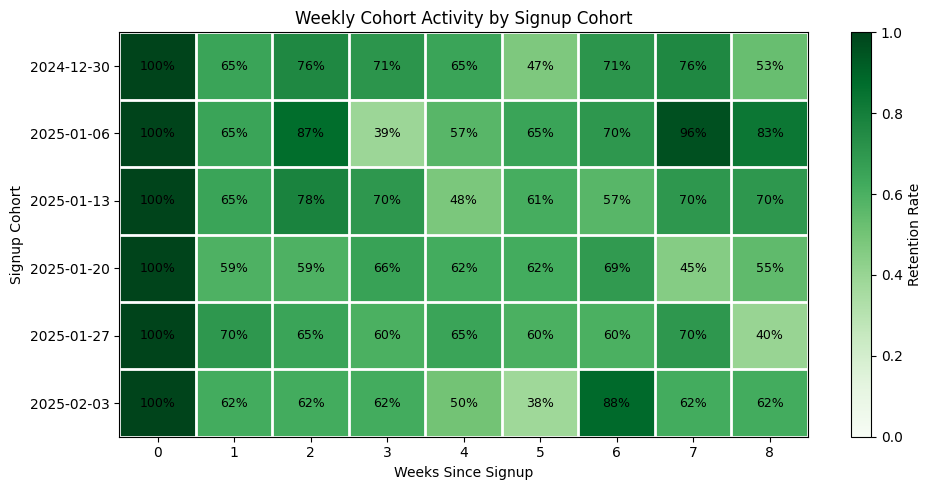

In [53]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 5))

im = plt.imshow(
    cohort_table,
    cmap="Greens",
    aspect="auto",
    vmin=0,
    vmax=1
)

# Add percentage labels inside each cell
for i in range(cohort_table.shape[0]):
    for j in range(cohort_table.shape[1]):
        plt.text(
            j,
            i,
            f"{cohort_table.iloc[i, j]:.0%}",
            ha="center",
            va="center",
            color="black",
            fontsize=9
        )

# Axis labels
plt.xticks(
    np.arange(len(cohort_table.columns)),
    cohort_table.columns
)

plt.yticks(
    np.arange(len(cohort_table.index)),
    cohort_table.index.strftime("%Y-%m-%d")
)

# Minor gridlines between cells
plt.gca().set_xticks(
    np.arange(-.5, len(cohort_table.columns), 1),
    minor=True
)

plt.gca().set_yticks(
    np.arange(-.5, len(cohort_table.index), 1),
    minor=True
)

plt.grid(
    which="minor",
    color="white",
    linewidth=2
)

plt.tick_params(which="minor", bottom=False, left=False)

cbar = plt.colorbar(im)
cbar.set_label("Retention Rate")

plt.xlabel("Weeks Since Signup")
plt.ylabel("Signup Cohort")
plt.title("Weekly Cohort Activity by Signup Cohort")

plt.tight_layout()
plt.show()

By Week 4, between 48% and 65% of users from each signup cohort remained active during the week. Although some variation between cohorts is expected, the fluctuations observed throughout the analysis suggest that engagement levels differ over time rather than following a simple downward trend. If similar patterns appeared in production data, I would investigate whether product updates, onboarding changes, or seasonal effects influenced clinician engagement. Additional analysis of user characteristics and feature adoption would help determine the underlying causes.

## Analyze the Product Conversion Funnel

A conversion funnel measures how users progress through the intended product workflow.

For this project, the expected workflow is:

1. Log into the platform.
2. Open a patient chart.
3. Accept an AI-generated insight.

Although the synthetic data are randomly generated, the analysis explicitly verifies that these events occur in the correct chronological order. This mirrors production analytics, where event logs may contain missing, duplicated, or out-of-order events due to logging delays, data ingestion issues, or system errors. Enforcing event order produces a more robust and realistic measure of user progression through the product.

In [54]:
# First occurrence of each event for every user
first_events = (
    events.pivot_table(
        index="user_id",
        columns="event_type",
        values="event_date",
        aggfunc="min"
    )
)

first_events.head()

event_type,accepted_insight,dismissed_insight,documented,login,opened_chart
user_id,,,,,
1,2025-03-06,NaT,2025-03-27,2025-01-29,2025-01-30
2,2025-01-15,2025-01-30,2025-03-07,2025-03-12,2025-01-17
3,2025-01-26,2025-01-15,2025-01-10,2025-01-21,2025-01-27
4,2025-02-19,2025-02-16,2025-03-05,2025-01-24,2025-03-22
5,2025-01-27,2025-02-04,NaT,2025-02-10,2025-02-05


In [55]:
# Stage 1: User logged in
stage_login = first_events["login"].notna()

# Stage 2: User opened a chart after logging in
stage_chart = (
    stage_login &
    first_events["opened_chart"].notna() &
    (first_events["opened_chart"] >= first_events["login"])
)

# Stage 3: User accepted an insight after opening a chart
stage_accept = (
    stage_chart &
    first_events["accepted_insight"].notna() &
    (first_events["accepted_insight"] >= first_events["opened_chart"])
)

login_count = stage_login.sum()
chart_count = stage_chart.sum()
accept_count = stage_accept.sum()

funnel = pd.DataFrame({
    "Stage": [
        "Logged In",
        "Opened Chart",
        "Accepted Insight"
    ],
    "Users": [
        login_count,
        chart_count,
        accept_count
    ]
})

funnel["Conversion from Previous (%)"] = [
    100.0,
    round(chart_count / login_count * 100, 1),
    round(accept_count / chart_count * 100, 1)
]

funnel["Overall Conversion (%)"] = [
    100.0,
    round(chart_count / login_count * 100, 1),
    round(accept_count / login_count * 100, 1)
]

funnel

,Stage,Users,Conversion from Previous (%),Overall Conversion (%)
0,Logged In,115,100.0,100.0
1,Opened Chart,64,55.7,55.7
2,Accepted Insight,23,35.9,20.0


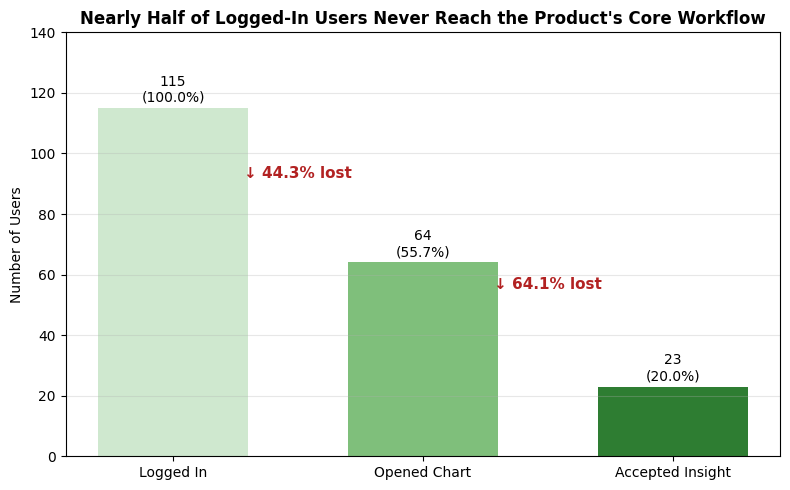

In [56]:
import matplotlib.pyplot as plt

stages = funnel["Stage"]
funnel_users = funnel["Users"] # Changed from 'users' to 'funnel_users' to avoid overwriting the original 'users' DataFrame

colors = ["#CFE8CF", "#7FBF7B", "#2E7D32"]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    stages,
    funnel_users, # Use funnel_users here
    color=colors,
    width=0.6
)

plt.ylabel("Number of Users")

plt.title(
    "Nearly Half of Logged-In Users Never Reach the Product's Core Workflow",
    fontsize=12,
    weight="bold"
)

# Counts and overall conversion
for i, bar in enumerate(bars):

    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 2,
        f"{funnel_users[i]}\n({funnel['Overall Conversion (%)'][i]}%)", # Use funnel_users here
        ha="center",
        fontsize=10
    )

# Step-to-step drop-off
drop1 = 100 - funnel["Conversion from Previous (%)"][1]
drop2 = 100 - funnel["Conversion from Previous (%)"][2]

plt.text(
    0.5,
    max(funnel_users)*0.80, # Use funnel_users here
    f"↓ {drop1:.1f}% lost",
    ha="center",
    color="firebrick",
    fontsize=11,
    weight="bold"
)

plt.text(
    1.5,
    max(funnel_users)*0.48, # Use funnel_users here
    f"↓ {drop2:.1f}% lost",
    ha="center",
    color="firebrick",
    fontsize=11,
    weight="bold"
)

plt.ylim(0, max(funnel_users)+25) # Use funnel_users here

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

The conversion funnel begins with all users at the login stage, which serves as the baseline for the analysis. From this point, 55.7% of users progressed to opening a patient chart, while 35.8% of those users went on to accept an AI-generated insight, resulting in an overall conversion rate of 20.0% from login to accepted insight.

The largest reduction therefore occurs before users reach the product's core workflow, suggesting that initial engagement with the platform may represent a greater opportunity for improvement than the AI recommendations themselves. However, the funnel alone cannot explain why users discontinue the workflow. Additional data, such as session-level interactions, feature usage patterns, or qualitative user feedback, would be required before drawing conclusions about the underlying causes of the observed drop-off.

## Define and Calculate the Engagement KPI

A key responsibility of product analysts is to define metrics that measure whether users are receiving value from a product. For a healthcare AI platform, simply tracking logins is insufficient because clinicians may log in without interacting with the AI-generated insights.

This project defines the following engagement KPI:

**Accepted Insights per Active Clinician per Week**

This metric measures the average number of AI-generated insights that active clinicians accept each week. It is calculated by:

1. Creating a weekly time period for every event.
2. Counting the total number of **accepted insight** events each week.
3. Counting the number of **active clinicians** (unique users with at least one event) each week.
4. Dividing the number of accepted insights by the number of active clinicians.

Using this normalized metric makes it possible to compare engagement across weeks, even when the number of active users changes. Because the product value depends on clinicians trusting and acting on AI recommendations, this KPI provides a meaningful indicator of product adoption beyond basic usage metrics.

In [57]:
events["week"] = (
    events["event_date"]
    .dt.to_period("W")
    .apply(lambda r: r.start_time)
)

accepted_weekly = (
    events[
        events.event_type == "accepted_insight"
    ]
    .groupby("week")
    .size()
)

active_weekly = (
    events.groupby("week")["user_id"]
    .nunique()
)

kpi = (
    accepted_weekly /
    active_weekly
).fillna(0)

kpi = kpi.rename(
    "accepted_insights_per_active_clinician"
)

kpi

,accepted_insights_per_active_clinician
week,
2024-12-30,0.142857
2025-01-06,0.222222
2025-01-13,0.230769
2025-01-20,0.241935
2025-01-27,0.250000
2025-02-03,0.239437
2025-02-10,0.226667
2025-02-17,0.256410
2025-02-24,0.237500


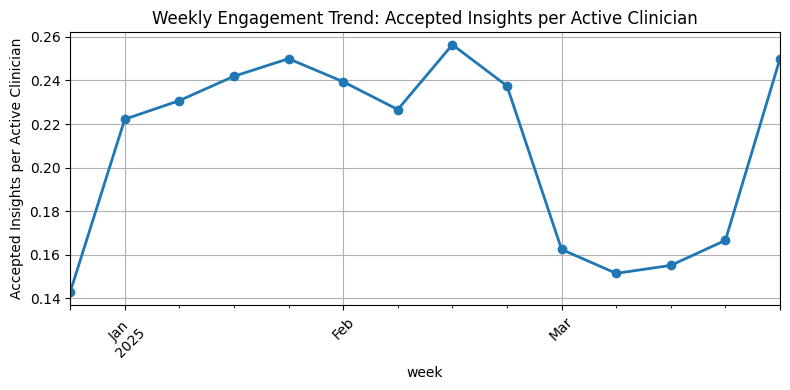

In [58]:
# Remove the last week if it is incomplete
last_date = events["event_date"].max()

# Week starts on Monday, so a complete week ends on Sunday
if last_date.weekday() != 6:   # Sunday = 6
    kpi_plot = kpi.iloc[:-1]
else:
    kpi_plot = kpi

plt.figure(figsize=(8, 4))

kpi_plot.plot(
    marker="o",
    linewidth=2,
    legend=False
)

plt.ylabel("Accepted Insights per Active Clinician")

plt.title("Weekly Engagement Trend: Accepted Insights per Active Clinician")

plt.grid(True)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

The engagement KPI increased during January and remained relatively stable throughout late January and February, with accepted insights per active clinician generally ranging between 0.22 and 0.26. During March, the metric declined to approximately 0.15–0.17, before recovering to 0.25 by the end of the observation period. Although this dataset is synthetic, a similar pattern in production data would prompt further investigation to determine whether the observed change reflected normal variation or was associated with product releases, workflow changes, or other external factors.

This KPI measures clinician interaction with AI-generated insights, but it should not be interpreted as a direct measure of product value. A clinician may appropriately reject an AI recommendation after considering additional clinical information, and such decisions may still reflect effective use of the system. For an AI-assisted clinical product, the objective is not to maximize acceptance of recommendations, but to support clinicians in making informed decisions. Consequently, this metric should be interpreted alongside complementary measures such as user retention, workflow completion, and, where available, clinical outcomes.

## Identify Users Showing a Drop-off Pattern

Product teams often seek to identify users who appear to be disengaging before they churn completely.

For this project, a user is considered to have entered a drop-off pattern if they:

- are active for at least two consecutive weeks, and
- subsequently remain inactive for the next two consecutive weeks.


In [59]:

# This implementation uses a Python loop because the synthetic
# dataset is small (~120 users). For production-scale data,
# this logic would typically be implemented using SQL window
# functions or vectorized pandas operations.

weekly_activity = (
    events.groupby(["user_id", "week"])
    .size()
    .reset_index(name="events")
)

# The 'week' column was created using:
# events["event_date"].dt.to_period("W").apply(lambda r: r.start_time)
# Since I use Monday as the start of the week,
# reindexing with freq="W-MON" ensures the weeks align correctly.

all_weeks = pd.date_range(
    start=events["week"].min(),
    end=events["week"].max(),
    freq="W-MON"
)

drop_off_users = []

for user in weekly_activity["user_id"].unique():

    user_activity = (
        weekly_activity[weekly_activity["user_id"] == user]
        .set_index("week")
        .reindex(all_weeks, fill_value=0)
    )

    user_activity["is_active"] = user_activity["events"] > 0

    activity = user_activity["is_active"].tolist()

    for i in range(len(activity) - 3):

        if (
            activity[i]
            and activity[i + 1]
            and not activity[i + 2]
            and not activity[i + 3]
        ):
            drop_off_users.append(user)
            break

drop_off_users = sorted(set(drop_off_users))

## Create a Summary of At-Risk Users

The final step stores the identified drop-off users in a separate table.

This list represents users whose engagement has declined according to the defined rule and can serve as the basis for future retention analyses, predictive churn models, or targeted outreach initiatives.

In [60]:

drop_off_df = (
    pd.DataFrame({"user_id": drop_off_users})
    .merge(users, on="user_id", how="left")
)

# Last week the user was active
drop_off_df["last_active_week"] = (
    drop_off_df["user_id"]
    .map(
        weekly_activity.groupby("user_id")["week"].max()
    )
)

# Number of weeks with activity
drop_off_df["weeks_active"] = (
    drop_off_df["user_id"]
    .map(
        weekly_activity.groupby("user_id")["week"].nunique()
    )
)

# Total number of events generated
drop_off_df["total_events"] = (
    drop_off_df["user_id"]
    .map(
        events.groupby("user_id").size()
    )
)

# Last recorded event before dropping off
last_event = (
    events.sort_values("event_date")
    .groupby("user_id")["event_type"]
    .last()
)

drop_off_df["last_event_type"] = (
    drop_off_df["user_id"].map(last_event)
)

# Display users in order of most recent activity
drop_off_df = (
    drop_off_df
    .sort_values("last_active_week", ascending=False)
    .reset_index(drop=True)
)

drop_off_df

,user_id,signup_date,last_active_week,weeks_active,total_events,last_event_type
0,51,2025-02-03,2025-04-07,8,11,login
1,87,2025-02-03,2025-04-07,5,7,opened_chart
2,15,2025-01-30,2025-04-07,6,7,accepted_insight
3,18,2025-02-02,2025-04-07,6,7,documented
4,62,2025-01-24,2025-03-31,7,9,dismissed_insight
...,...,...,...,...,...,...
79,98,2025-01-03,2025-02-24,5,8,accepted_insight
80,54,2025-01-31,2025-02-17,3,4,opened_chart
81,95,2025-01-01,2025-02-17,4,9,opened_chart
82,111,2025-01-04,2025-02-17,7,12,opened_chart


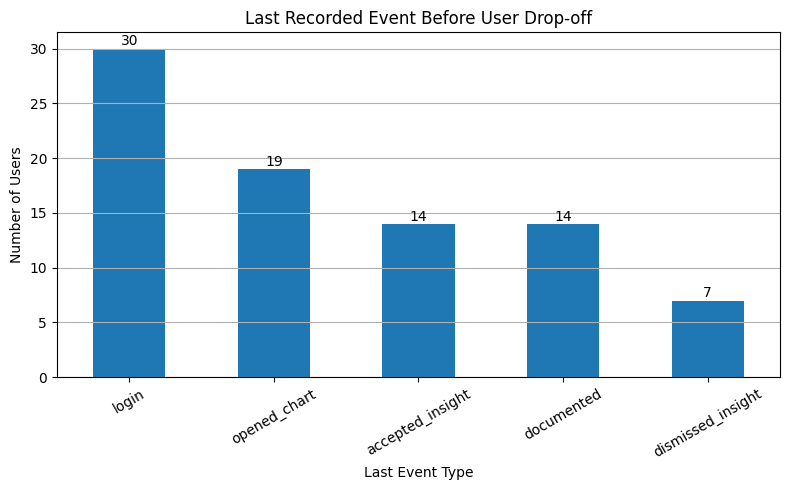

In [61]:
import matplotlib.pyplot as plt

# Count the last event type of users who dropped off
last_event_counts = (
    drop_off_df["last_event_type"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

last_event_counts.plot(kind="bar")

plt.title("Last Recorded Event Before User Drop-off")
plt.xlabel("Last Event Type")
plt.ylabel("Number of Users")

plt.xticks(rotation=30)
plt.grid(axis="y")

# Add value labels
for i, value in enumerate(last_event_counts):
    plt.text(i, value + 0.3, str(value), ha="center")

plt.tight_layout()
plt.show()

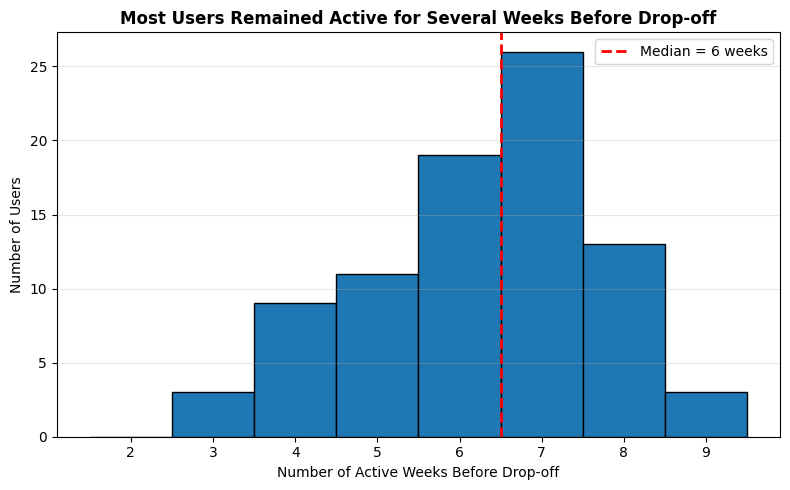

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

# Histogram of active weeks before drop-off
plt.hist(
    drop_off_df["weeks_active"],
    bins=range(2, 11),
    align="left",
    edgecolor="black"
)

# Median weeks active
median_weeks = drop_off_df["weeks_active"].median()

plt.axvline(
    median_weeks,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Median = {median_weeks:.0f} weeks"
)

plt.title(
    "Most Users Remained Active for Several Weeks Before Drop-off",
    fontsize=12,
    weight="bold"
)

plt.xlabel("Number of Active Weeks Before Drop-off")
plt.ylabel("Number of Users")

plt.xticks(range(2, 10))

plt.grid(axis="y", alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()

The drop-off analysis identified users who were active for at least two consecutive weeks before becoming inactive for two consecutive weeks. Many of the flagged users had accumulated 6–9 active weeks and 8–15 recorded events before disengaging, indicating that the detected users were not simply new users who failed to adopt the product. Several users also completed meaningful actions, such as accepting AI-generated insights or documenting clinical notes, before becoming inactive.

Although the dataset is synthetic, this pattern illustrates an important distinction between initial adoption and long-term engagement. In a production environment, these users would represent a high-value group for further investigation because they had already demonstrated sustained engagement with the platform before discontinuing use. Understanding why previously engaged clinicians stop returning could provide more actionable product insights than focusing solely on users who never adopted the workflow. Additional data—such as user feedback, workflow changes, or organizational factors—would be needed to determine the underlying causes of disengagement.

# Discussion

This project demonstrates a typical product analytics workflow using a synthetic event dataset that simulates interactions with a healthcare AI platform. The analyses focused on four fundamental aspects of product analytics: retention, workflow conversion, user engagement, and early detection of user disengagement. Although the dataset is synthetic, the analytical methods and product questions mirror those commonly encountered in healthcare SaaS environments.

The cohort analysis showed that user activity varied across signup cohorts, with approximately 48%–65% of each cohort remaining active by Week 4. Rather than treating these differences as evidence of a product issue, they should be viewed as signals that warrant further investigation. In a production environment, similar variation could reflect differences in onboarding, product releases, acquisition channels, or seasonal effects. An important limitation of this analysis is that it measures weekly activity by cohort, allowing users to return after periods of inactivity, rather than traditional cumulative retention. The appropriate definition should ultimately depend on the business question being addressed.

The conversion funnel demonstrated that while every user entered the analysis at the login stage, only 55.7% progressed to opening a patient chart. Among those users, 35.8% accepted an AI-generated insight, corresponding to an overall conversion rate of 20.0% from login to accepted insight. The largest reduction therefore occurred before clinicians reached the product's primary workflow, suggesting that encouraging users to engage with the platform's core functionality may represent a greater opportunity than attempting to increase AI acceptance alone. At the same time, the funnel cannot explain why users left the workflow. Additional evidence, such as session-level interactions, workflow observations, or qualitative user feedback, would be required before attributing the drop-off to any specific cause.

To measure engagement, this project introduced the KPI Accepted Insights per Active Clinician per Week. During most of the observation period, the metric remained relatively stable, with values generally ranging between 0.22 and 0.26 accepted insights per active clinician, before temporarily declining during March and recovering by the end of the observation period. If a similar pattern were observed in production, it would justify further investigation to determine whether the change reflected normal variation or was associated with product updates, workflow changes, or external factors.

More importantly, this project deliberately questions whether acceptance should be considered the primary measure of product success. In clinical decision support systems, clinicians should evaluate AI recommendations critically rather than accept them by default. An insight that is ultimately dismissed may still provide value by prompting the clinician to review additional patient information, reconsider a diagnosis, or confirm an alternative course of action. Consequently, acceptance should be interpreted as a measure of interaction with AI-generated recommendations rather than a direct measure of product effectiveness.

This observation highlights a broader principle in product analytics: metrics influence behavior. Optimizing exclusively for insight acceptance could unintentionally encourage interface changes that increase acceptance rates without improving clinical decision-making. For example, making the Accept option more visually prominent than Dismiss, or introducing unnecessary friction when rejecting recommendations, could inflate the KPI while reducing the quality and independence of clinical decisions. Such deceptive design practices would conflict with the purpose of a clinical decision support system, whose objective is to assist clinicians rather than persuade them to follow AI recommendations.

For this reason, engagement should always be evaluated using multiple complementary measures rather than a single KPI. Metrics such as clinician retention, workflow completion, frequency of AI recommendation review, documentation efficiency, repeat usage of AI-assisted features, and—where available—clinical outcomes together provide a more comprehensive understanding of whether the product is creating meaningful value for clinicians and patients.

The drop-off analysis identified users who remained engaged for 6–9 active weeks and accumulated 8–15 events before becoming inactive for at least two consecutive weeks. Several users also completed meaningful actions, including accepting AI-generated insights or documenting clinical notes, before disengaging. This suggests that the detected users were not simply new users who failed to adopt the product, but users who had already integrated the platform into their workflow before reducing their activity. In a production environment, this group would represent an especially valuable population for further investigation, as understanding why previously engaged clinicians disengage is likely to produce more actionable product improvements than focusing solely on users who never adopted the workflow. At the same time, the drop-off rule used here provides only one operational definition of disengagement and does not distinguish between temporary inactivity and permanent churn. A production implementation would likely incorporate longer inactivity periods, user segmentation, or additional behavioral signals.

Overall, this project illustrates that effective product analytics extends beyond calculating metrics. Analysts must evaluate whether the chosen measures genuinely reflect user value, understand their limitations, and avoid drawing causal conclusions that are not supported by the available data. Equally important, they should consider how optimization incentives influence both product design and user behavior. In healthcare AI, success is not defined by maximizing AI acceptance or engagement alone, but by supporting clinicians in making informed decisions that improve patient care. The role of product analytics is therefore not only to measure behavior, but also to ensure that the metrics being optimized remain aligned with the product's clinical purpose.